Epoch 1/50


/home/ailab/anaconda3/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 2/50
Epoch 3/50
Epoch 4/50
Epoch 5/50
Epoch 6/50
Epoch 7/50
Epoch 8/50
Epoch 9/50
Epoch 10/50
Epoch 11/50
Epoch 12/50
Epoch 13/50
Epoch 14/50
Epoch 15/50
Epoch 16/50
Epoch 17/50
Epoch 18/50
Epoch 19/50
Epoch 20/50
Epoch 21/50
Epoch 22/50
Epoch 23/50
Epoch 24/50
Epoch 25/50
Epoch 26/50
Epoch 27/50
Epoch 28/50
Epoch 29/50
Epoch 30/50
Epoch 31/50
Epoch 32/50
Epoch 33/50
Epoch 34/50
Epoch 35/50
Epoch 36/50
Epoch 37/50
Epoch 38/50
Epoch 39/50
Epoch 40/50
Epoch 41/50
Epoch 42/50
Epoch 43/50
Epoch 44/50
Epoch 45/50
Epoch 46/50
Epoch 47/50
Epoch 48/50
Epoch 49/50
Epoch 50/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


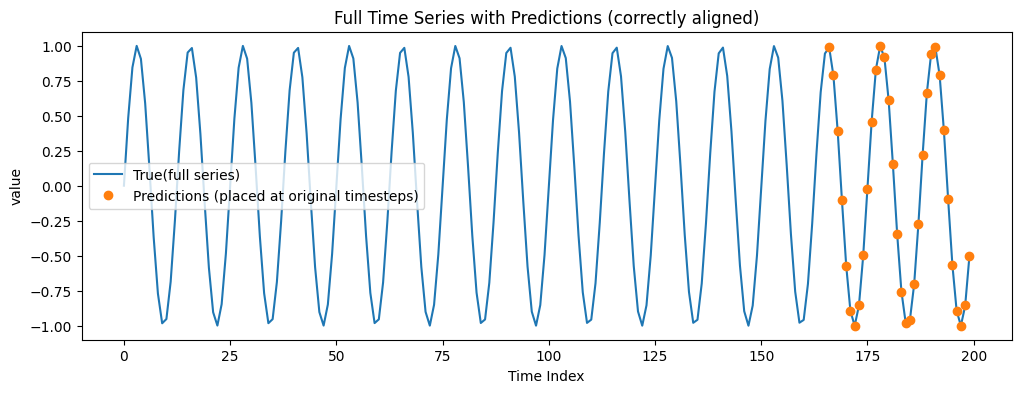

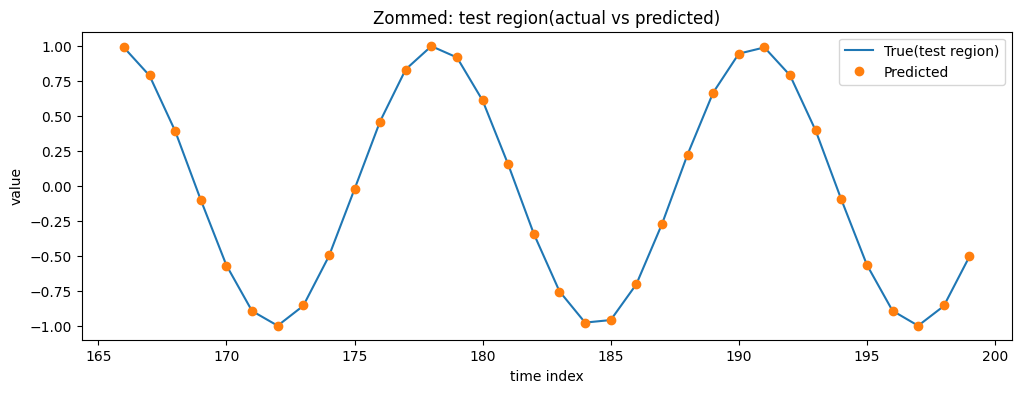

sample actual vs predicted values(test window):
index 166->Actual:0.9864	 Predicted:0.9914
index 167->Actual:0.7854	 Predicted:0.7914
index 168->Actual:0.3902	 Predicted:0.3935
index 169->Actual:-0.1014	 Predicted:-0.1017
index 170->Actual:-0.5680	 Predicted:-0.5706
index 171->Actual:-0.8942	 Predicted:-0.8967
index 172->Actual:-0.9993	 Predicted:-0.9986
index 173->Actual:-0.8573	 Predicted:-0.8527
index 174->Actual:-0.5033	 Predicted:-0.4980
index 175->Actual:-0.0249	 Predicted:-0.0230


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense
from sklearn.preprocessing import MinMaxScaler

data=np.sin(np.linspace(0,100,200)).reshape(-1,1)

scaler=MinMaxScaler(feature_range=(0,1))
data_scaled=scaler.fit_transform(data)

window_size=30
X,y=[],[]
for i in range(len(data_scaled)-window_size):
    X.append(data_scaled[i:i+window_size])
    y.append(data_scaled[i+window_size])
X=np.array(X)
y=np.array(y)

split=int(0.8 * len(X))
X_train,X_test=X[:split],X[split:]
y_train,y_test=y[:split],y[split:]

model=Sequential([
        LSTM(50,activation='tanh',input_shape=(window_size,1)),Dense(1)
    ])
model.compile(optimizer='adam',loss='mse')

model.fit(X_train,y_train,epochs=50,batch_size=16,validation_data=(X_test,y_test),verbose=50)

pred_scaled=model.predict(X_test)
pred=scaler.inverse_transform(pred_scaled)
y_test_inv=scaler.inverse_transform(y_test)

data_full=data.flatten()
pred_full=np.full_like(data_full,np.nan)

for i in range(len(pred)):
    orig_index=window_size+split+i 
    pred_full[orig_index]=pred[i,0]

plt.figure(figsize=(12,4))
plt.plot(data_full,label='True(full series)')
plt.plot(pred_full,marker='o',linestyle='',label='Predictions (placed at original timesteps)')
plt.title('Full Time Series with Predictions (correctly aligned)')
plt.legend()
plt.xlabel('Time Index')
plt.ylabel('value')
plt.show()

test_start=window_size+split
test_end=len(data_full)
plt.figure(figsize=(12,4))
plt.plot(range(test_start,test_end),data_full[test_start:test_end],label='True(test region)')
plt.plot(range(test_start,test_end),pred_full[test_start:test_end],marker='o',linestyle='',label='Predicted')
plt.title('Zommed: test region(actual vs predicted)')
plt.legend()
plt.xlabel('time index')
plt.ylabel('value')
plt.show()

print("sample actual vs predicted values(test window):")

for i in range(min(10,len(pred))):
    actual=float(y_test_inv[i, 0])
    predicted_value=float(pred[i, 0])
    print(f"index {window_size+split+i:03d}->Actual:{actual:.4f}\t Predicted:{predicted_value:.4f}")
